In [7]:
!pip -q install \
numpy \
pandas \
matplotlib \
plotly \
scipy \
pyarrow \
tqdm

In [8]:
import gc
import json
import logging
import warnings

from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

import plotly.express as px
import plotly.graph_objects as go

from tqdm.notebook import tqdm

warnings.filterwarnings("ignore")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [9]:

PROJECT_NAME = "Exoplanet-detection"

ROOT_DIR = Path('D:/MachineLearning/Exoplanet-detection')

PROCESSED_DIR = ROOT_DIR / "data" / "processed" / "lightcurves"

REPORT_DIR = ROOT_DIR / "reports"

FIGURE_DIR = REPORT_DIR / "figures"

LOG_DIR = ROOT_DIR / "logs"

REPORT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
LOG_DIR.mkdir(parents=True, exist_ok=True)

print("Configuration Loaded")

Configuration Loaded


In [10]:
LOG_FILE = LOG_DIR / "notebook_data_quality_analysis.log"

logging.basicConfig(
    level=logging.INFO,
    format="%(asctime)s | %(levelname)s | %(message)s",
    handlers=[
        logging.FileHandler(LOG_FILE),
        logging.StreamHandler()
    ],
    force=True
)

logger = logging.getLogger("NotebookQualityAnalysis")

logger.info("Notebook Quality analysis  Started")

2026-07-23 23:21:12,702 | INFO | Notebook Quality analysis  Started


In [11]:
processed_files = sorted(PROCESSED_DIR.glob("*.parquet"))

print(f"Processed Files Found : {len(processed_files):,}")


if len(processed_files):

    print(processed_files[0])

else:

    print("No processed light curves found.")

Processed Files Found : 89
D:\MachineLearning\Exoplanet-detection\data\processed\lightcurves\TIC_100990000_Sector_3.parquet


In [12]:
sample = pd.read_parquet(processed_files[0])

sample.head()

,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality,trend
0,100990000,3,TESS,SPOC,100990000,21.661595,1385.950975,0.999648,40.051029,0,128491.154483
1,100990000,3,TESS,SPOC,100990000,21.661595,1385.952364,1.000761,40.076237,0,128491.278858
2,100990000,3,TESS,SPOC,100990000,21.661595,1385.953753,1.000269,40.061535,0,128491.029725
3,100990000,3,TESS,SPOC,100990000,21.661595,1385.955142,0.999865,40.054287,0,128490.664490
4,100990000,3,TESS,SPOC,100990000,21.661595,1385.956531,1.000046,40.054855,0,128490.364681


In [13]:
print(sample.info())

display(sample.describe(include="all"))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13532 entries, 0 to 13531
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   tic_id       13532 non-null  int64  
 1   sector       13532 non-null  int64  
 2   mission      13532 non-null  object 
 3   author       13532 non-null  object 
 4   target_name  13532 non-null  int64  
 5   cadence_sec  13532 non-null  float64
 6   time         13532 non-null  float64
 7   flux         13532 non-null  float64
 8   flux_err     13532 non-null  float32
 9   quality      13532 non-null  int32  
 10  trend        13532 non-null  float64
dtypes: float32(1), float64(4), int32(1), int64(3), object(2)
memory usage: 1.0+ MB
None


,tic_id,sector,mission,author,target_name,cadence_sec,time,flux,flux_err,quality,trend
count,13532.0,13532.0,13532,13532,13532.0,1.353200e+04,13532.000000,13532.000000,13532.000000,13532.0,13532.000000
unique,NaN,NaN,1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,TESS,SPOC,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,13532,13532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1396.085615,1.000003,40.117222,0.0,128490.586597
std,0.0,0.0,NaN,NaN,0.0,1.065853e-14,6.037814,0.000316,0.236273,0.0,7.371790
min,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1385.950975,0.998790,40.024426,0.0,128471.574302
25%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1390.703520,0.999793,40.049965,0.0,128486.451715
50%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1396.708842,1.000000,40.057339,0.0,128490.487245
75%,100990000.0,3.0,NaN,NaN,100990000.0,2.166159e+01,1401.451633,1.000214,40.065331,0.0,128495.523097


In [14]:
missing = sample.isnull().sum()

display(missing)

tic_id         0
sector         0
mission        0
author         0
target_name    0
cadence_sec    0
time           0
flux           0
flux_err       0
quality        0
trend          0
dtype: int64

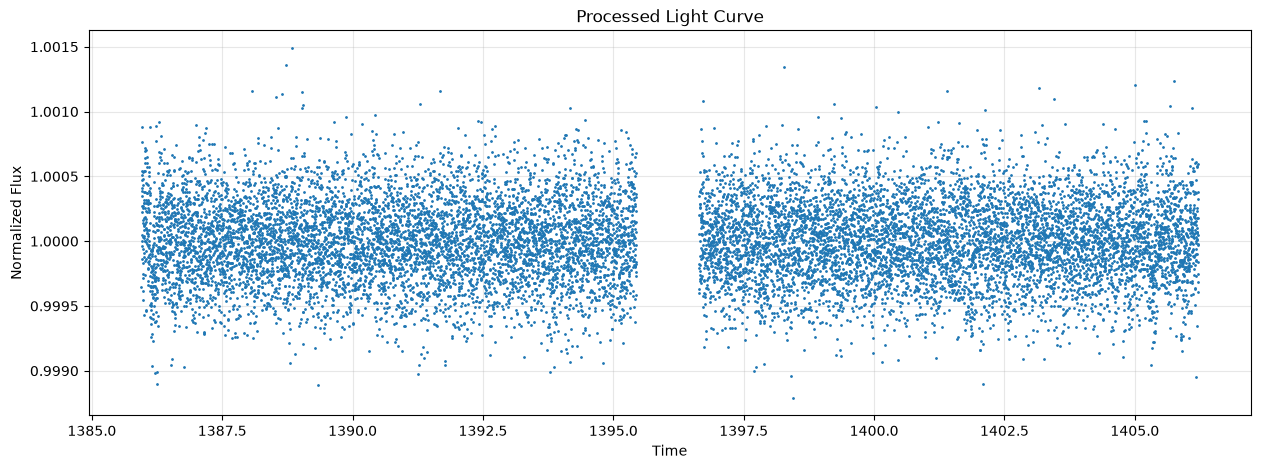

In [15]:
#Visualize the data quality of the dataset

plt.figure(figsize=(15,5))

plt.plot(
    sample["time"],
    sample["flux"],
    ".",
    markersize=2
)

plt.xlabel("Time")

plt.ylabel("Normalized Flux")

plt.title("Processed Light Curve")

plt.grid(alpha=0.3)

plt.show()

In [16]:

metadata_columns = [

    "tic_id",

    "sector",

    "mission",

    "author",

    "target_name",

    "cadence_sec"

]

available = []

for col in metadata_columns:

    if col in sample.columns:

        available.append(col)

print("Metadata Columns Available")

print(available)

Metadata Columns Available
['tic_id', 'sector', 'mission', 'author', 'target_name', 'cadence_sec']


In [17]:
# Additional Statistical Imports

from scipy.stats import skew
from scipy.stats import kurtosis
from scipy.stats import median_abs_deviation

print("Statistical functions loaded.")

Statistical functions loaded.


In [18]:
def compute_basic_statistics(df):

    flux = df["flux"].values

    return {

        "num_points": len(df),

        "mean_flux": float(np.mean(flux)),

        "median_flux": float(np.median(flux)),

        "std_flux": float(np.std(flux)),

        "variance": float(np.var(flux)),

        "min_flux": float(np.min(flux)),

        "max_flux": float(np.max(flux)),

        "dynamic_range": float(np.max(flux) - np.min(flux))

    }

In [19]:
# Compute noise metrics 
def compute_noise_metrics(df):

    flux = df["flux"].values

    rms = np.sqrt(np.mean((flux - np.mean(flux)) ** 2))

    mad = median_abs_deviation(
        flux,
        scale="normal"
    )

    return {

        "rms": float(rms),

        "mad": float(mad),

        "snr": float(np.median(flux) / np.std(flux))

    }

In [20]:
# Time series metrics
def compute_time_metrics(df):

    time = df["time"].values

    duration = np.max(time) - np.min(time)

    cadence = np.median(np.diff(time))

    max_gap = np.max(np.diff(time))

    return {

        "duration_days": float(duration),

        "median_cadence_days": float(cadence),

        "max_gap_days": float(max_gap)

    }

In [21]:
#   Distribution metrics

def compute_distribution_metrics(df):

    flux = df["flux"].values

    return {

        "skewness": float(skew(flux)),

        "kurtosis": float(kurtosis(flux))

    }

In [22]:
#  Data Quality Metrics 
def compute_quality_metrics(df):

    total = len(df)

    missing = df.isnull().sum().sum()

    duplicates = df["time"].duplicated().sum()

    return {

        "missing_values": int(missing),

        "duplicate_times": int(duplicates),

        "missing_fraction": float(missing / total),

        "duplicate_fraction": float(duplicates / total)

    }
    

In [23]:
def compute_transit_metrics(df):

    flux = df["flux"].values

    baseline = np.median(flux)

    minimum = np.min(flux)

    depth = baseline - minimum

    return {

        "estimated_transit_depth": float(depth),

        "lowest_flux": float(minimum)

    }

In [24]:
def extract_metadata(df):

    metadata = {}

    columns = [

        "tic_id",

        "sector",

        "mission",

        "author",

        "target_name",

        "cadence_sec"

    ]

    for col in columns:

        if col in df.columns:

            metadata[col] = df[col].iloc[0]

        else:

            metadata[col] = np.nan

    return metadata

In [25]:
def analyze_lightcurve(df):

    report = {}

    report.update(extract_metadata(df))

    report.update(compute_basic_statistics(df))

    report.update(compute_noise_metrics(df))

    report.update(compute_time_metrics(df))

    report.update(compute_distribution_metrics(df))

    report.update(compute_quality_metrics(df))

    report.update(compute_transit_metrics(df))

    return report

In [26]:
# Test on sample 
sample_report = analyze_lightcurve(sample)

for key, value in sample_report.items():

    print(f"{key:30s} : {value}")

tic_id                         : 100990000
sector                         : 3
mission                        : TESS
author                         : SPOC
target_name                    : 100990000
cadence_sec                    : 21.661594559092
num_points                     : 13532
mean_flux                      : 1.0000030469728334
median_flux                    : 1.0
std_flux                       : 0.00031573743417790046
variance                       : 9.969012734124404e-08
min_flux                       : 0.9987898914930737
max_flux                       : 1.0014903198501972
dynamic_range                  : 0.0027004283571234744
rms                            : 0.00031573743417790046
mad                            : 0.000312011833172022
snr                            : 3167.18859328082
duration_days                  : 20.26564104584463
median_cadence_days            : 0.001388914169410782
max_gap_days                   : 1.2000230834064496
skewness                       : 0.0693

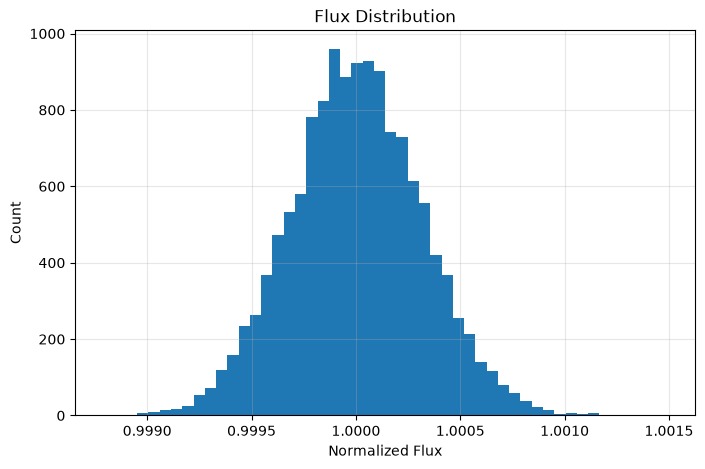

In [27]:
# Histogram of the data 
plt.figure(figsize=(8,5))

plt.hist(
    sample["flux"],
    bins=50
)

plt.xlabel("Normalized Flux")

plt.ylabel("Count")

plt.title("Flux Distribution")

plt.grid(alpha=0.3)

plt.show()

AttributeError: 'Series' object has no attribute 'standard_deviation'

In [32]:
quality_reports = []

print(f"Analyzing {len(processed_files)} processed light curves...")

for file in tqdm(processed_files):

    try:

        df = pd.read_parquet(file)

        report = analyze_lightcurve(df)

        report["file_name"] = file.name

        report["status"] = "Success"

        quality_reports.append(report)

    except Exception as e:

        logger.error(f"{file.name}: {e}")

        quality_reports.append({

            "file_name": file.name,

            "status": "Failed",

            "error": str(e)

        })

print("Analysis Completed.")

Analyzing 89 processed light curves...


  0%|          | 0/89 [00:00<?, ?it/s]

Analysis Completed.


In [33]:
quality_df = pd.DataFrame(quality_reports)

print(f"Rows : {len(quality_df)}")
print(f"Columns : {len(quality_df.columns)}")

quality_df.head()

Rows : 89
Columns : 30


,tic_id,sector,mission,author,target_name,cadence_sec,num_points,mean_flux,median_flux,std_flux,...,skewness,kurtosis,missing_values,duplicate_times,missing_fraction,duplicate_fraction,estimated_transit_depth,lowest_flux,file_name,status
0,100990000,3,TESS,SPOC,100990000,21.661595,13532,1.000003,1.0,0.000316,...,0.069340,0.132021,0,0,0.0,0.0,0.001210,0.998790,TIC_100990000_Sector_3.parquet,Success
1,120252452,40,TESS,SPOC,120252452,22.335620,19611,1.000077,1.0,0.008784,...,0.010462,0.111957,0,0,0.0,0.0,0.034610,0.965390,TIC_120252452_Sector_40.parquet,Success
2,120422519,53,TESS,SPOC,120422519,19.787113,16991,0.999908,1.0,0.014823,...,-0.012335,0.062769,0,0,0.0,0.0,0.062193,0.937807,TIC_120422519_Sector_53.parquet,Success
3,120691237,80,TESS,SPOC,120691237,20.947567,17255,0.999880,1.0,0.018543,...,-0.019136,0.361775,0,0,0.0,0.0,0.083770,0.916230,TIC_120691237_Sector_80.parquet,Success
4,121395761,40,TESS,SPOC,121395761,22.335706,19609,0.999922,1.0,0.019285,...,-0.009120,0.115879,0,0,0.0,0.0,0.079758,0.920242,TIC_121395761_Sector_40.parquet,Success


In [34]:
quality_csv = REPORT_DIR / "quality_metrics.csv"

quality_df.to_csv(
    quality_csv,
    index=False
)

logger.info("Quality metrics saved.")

2026-07-23 23:27:53,217 | INFO | Quality metrics saved.


In [35]:
#Outlier Detection
quality_success = quality_df[
    quality_df["status"] == "Success"
].copy()

rms_threshold = quality_success["rms"].quantile(0.99)

snr_threshold = quality_success["snr"].quantile(0.05)

outliers = quality_success[

    (quality_success["rms"] > rms_threshold)

    |

    (quality_success["snr"] < snr_threshold)

]

print(f"Detected {len(outliers)} potential outliers")

outliers.head()

Detected 5 potential outliers


,tic_id,sector,mission,author,target_name,cadence_sec,num_points,mean_flux,median_flux,std_flux,...,skewness,kurtosis,missing_values,duplicate_times,missing_fraction,duplicate_fraction,estimated_transit_depth,lowest_flux,file_name,status
37,164524311,75,TESS,SPOC,164524311,21.937633,19474,1.000080,1.0,0.051207,...,0.000184,0.229219,0,0,0.0,0.0,0.260865,0.739135,TIC_164524311_Sector_75.parquet,Success
58,271767300,40,TESS,SPOC,271767300,22.335929,19610,1.000219,1.0,0.063400,...,0.016300,-0.003613,0,0,0.0,0.0,0.249138,0.750862,TIC_271767300_Sector_40.parquet,Success
59,271959909,81,TESS,SPOC,271959909,21.087114,18410,1.000112,1.0,0.054535,...,0.017476,0.112627,0,0,0.0,0.0,0.220037,0.779963,TIC_271959909_Sector_81.parquet,Success
62,272719153,81,TESS,SPOC,272719153,21.087160,17741,1.000035,1.0,0.054155,...,-0.032448,0.166652,0,0,0.0,0.0,0.230131,0.769869,TIC_272719153_Sector_81.parquet,Success
69,273681023,76,TESS,SPOC,273681023,21.447098,19024,0.999675,1.0,0.072415,...,-0.019867,0.125962,0,0,0.0,0.0,0.294812,0.705188,TIC_273681023_Sector_76.parquet,Success


In [36]:
outlier_file = REPORT_DIR / "outlier_lightcurves.csv"

outliers.to_csv(
    outlier_file,
    index=False
)

logger.info("Outlier report saved.")

2026-07-23 23:28:39,240 | INFO | Outlier report saved.


In [37]:
best_curves = quality_success.sort_values(
    by="snr",
    ascending=False
).head(10)

best_curves[
    [
        "tic_id",
        "sector",
        "snr",
        "rms",
        "estimated_transit_depth"
    ]
]

,tic_id,sector,snr,rms,estimated_transit_depth
50,267519701,10,4276.817210,0.000234,0.000939
0,100990000,3,3167.188593,0.000316,0.001210
87,75673519,91,3105.371882,0.000322,0.001368
43,230061010,14,2887.466069,0.000346,0.002261
88,80224448,44,2731.292637,0.000366,0.001580
82,407090552,12,1381.160139,0.000724,0.003439
25,158002130,14,938.391057,0.001066,0.004568
24,152476657,4,616.699092,0.001622,0.008010
44,230127302,14,510.972475,0.001957,0.007327
38,164527695,26,422.144341,0.002369,0.010402


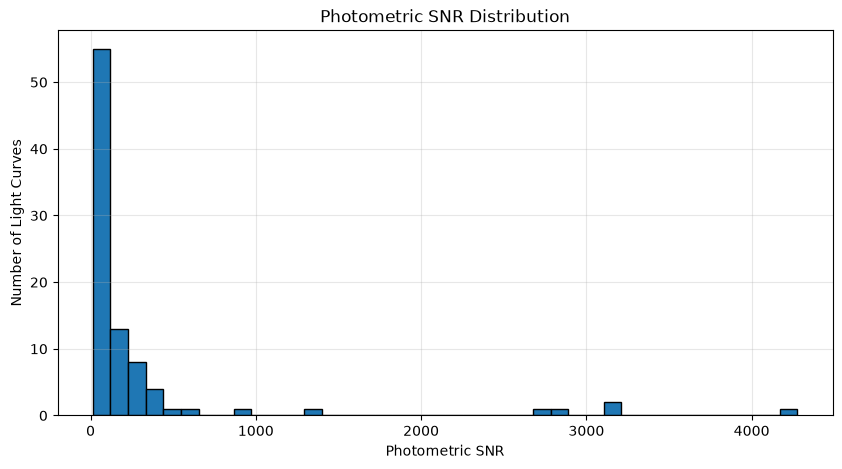

In [38]:

snr_column = "photometric_snr" if "photometric_snr" in quality_success.columns else "snr"

plt.figure(figsize=(10,5))

plt.hist(
    quality_success[snr_column],
    bins=40,
    edgecolor="black"
)

plt.title("Photometric SNR Distribution")

plt.xlabel("Photometric SNR")

plt.ylabel("Number of Light Curves")

plt.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "snr_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

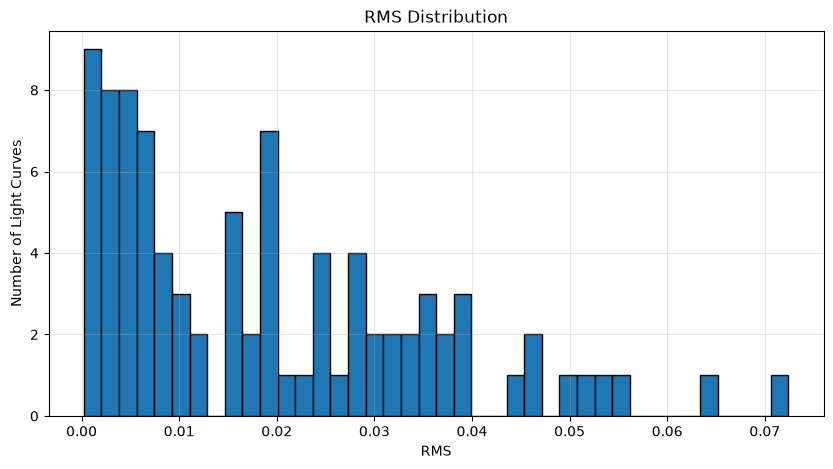

In [39]:
plt.figure(figsize=(10,5))

plt.hist(
    quality_success["rms"],
    bins=40,
    edgecolor="black"
)

plt.title("RMS Distribution")

plt.xlabel("RMS")

plt.ylabel("Number of Light Curves")

plt.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "rms_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

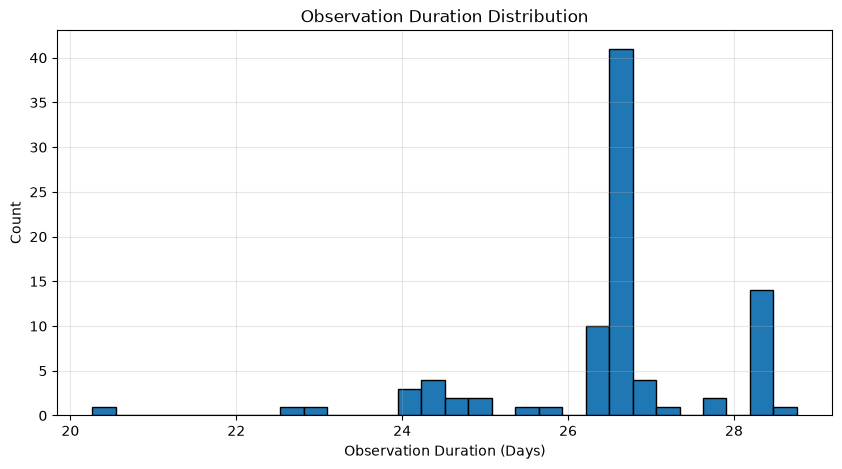

In [40]:
plt.figure(figsize=(10,5))

plt.hist(
    quality_success["duration_days"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Observation Duration (Days)")

plt.ylabel("Count")

plt.title("Observation Duration Distribution")

plt.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "duration_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

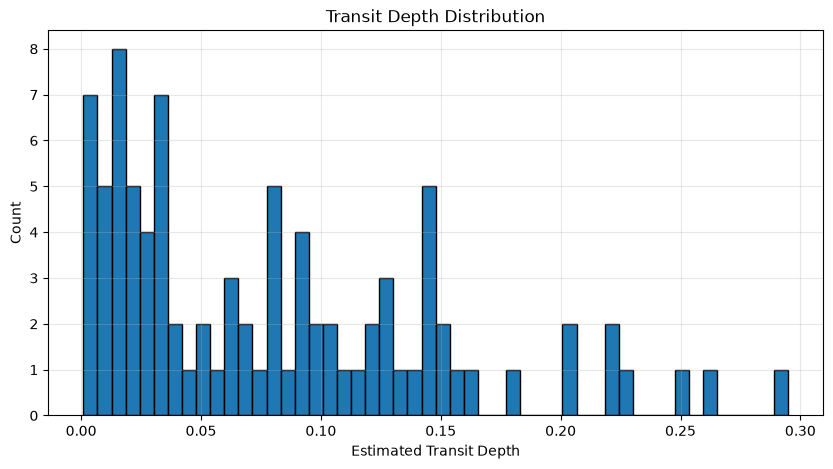

In [41]:
plt.figure(figsize=(10,5))

plt.hist(
    quality_success["estimated_transit_depth"],
    bins=50,
    edgecolor="black"
)

plt.xlabel("Estimated Transit Depth")

plt.ylabel("Count")

plt.title("Transit Depth Distribution")

plt.grid(alpha=0.3)

plt.savefig(
    FIGURE_DIR / "transit_depth_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [42]:
fig = px.scatter(

    quality_success,

    x="rms",

    y=snr_column,

    hover_data=["tic_id","sector"],

    title="RMS vs Photometric SNR"

)

fig.show()

fig.write_html(
    FIGURE_DIR / "rms_vs_snr.html"
)

In [43]:

numeric = quality_success.select_dtypes(include=np.number)

corr = numeric.corr()

fig = px.imshow(

    corr,

    text_auto=".2f",

    aspect="auto",

    color_continuous_scale="Viridis",

    title="Quality Metric Correlation"

)

fig.show()

fig.write_html(
    FIGURE_DIR / "correlation_heatmap.html"
)

In [44]:
fig = px.box(

    quality_success,

    y=["rms", snr_column],

    title="Outlier Detection"

)

fig.show()

fig.write_html(
    FIGURE_DIR / "boxplots.html"
)

In [45]:
dashboard = px.scatter(

    quality_success,

    x="duration_days",

    y=snr_column,

    color="rms",

    hover_data=[

        "tic_id",

        "sector",

        "estimated_transit_depth"

    ],

    title="Dataset Quality Dashboard"

)

dashboard.show()

dashboard.write_html(

    FIGURE_DIR / "quality_dashboard.html"

)